In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [16]:
df= df.drop_duplicates()

print(f"Clean dataset shape :{df.shape}")

Clean dataset shape :(302, 14)


In [17]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

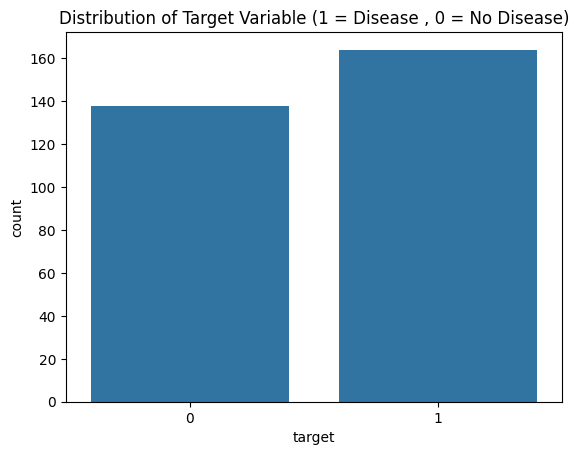

In [18]:
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable (1 = Disease , 0 = No Disease)')
plt.show()

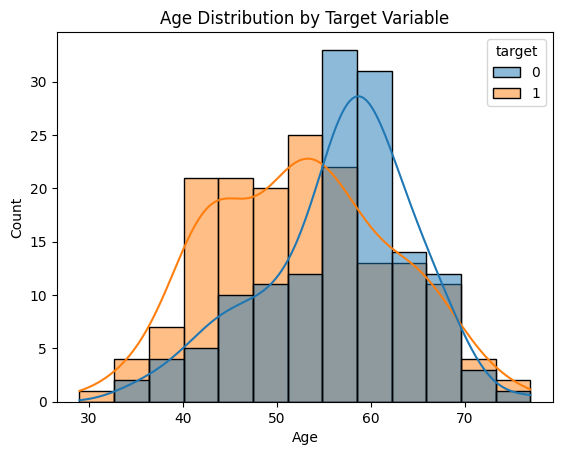

In [19]:
# Age distribution by target 

sns.histplot(data=df, x='age', hue='target', kde=True)
plt.title('Age Distribution by Target Variable')
plt.xlabel('Age')
plt.ylabel('Count') 
plt.show()

We can clearly see that orange peaks around 40-55 meaning younger people tend to have heart disease in this dataset. Blue peaks around 55-65 showing older people surprisingly less disease. 

What this tells us : Older peatients may have already been treated or removed from the sample. this is selection bias

Key takeaway: Age alone won't be a strong predictor here


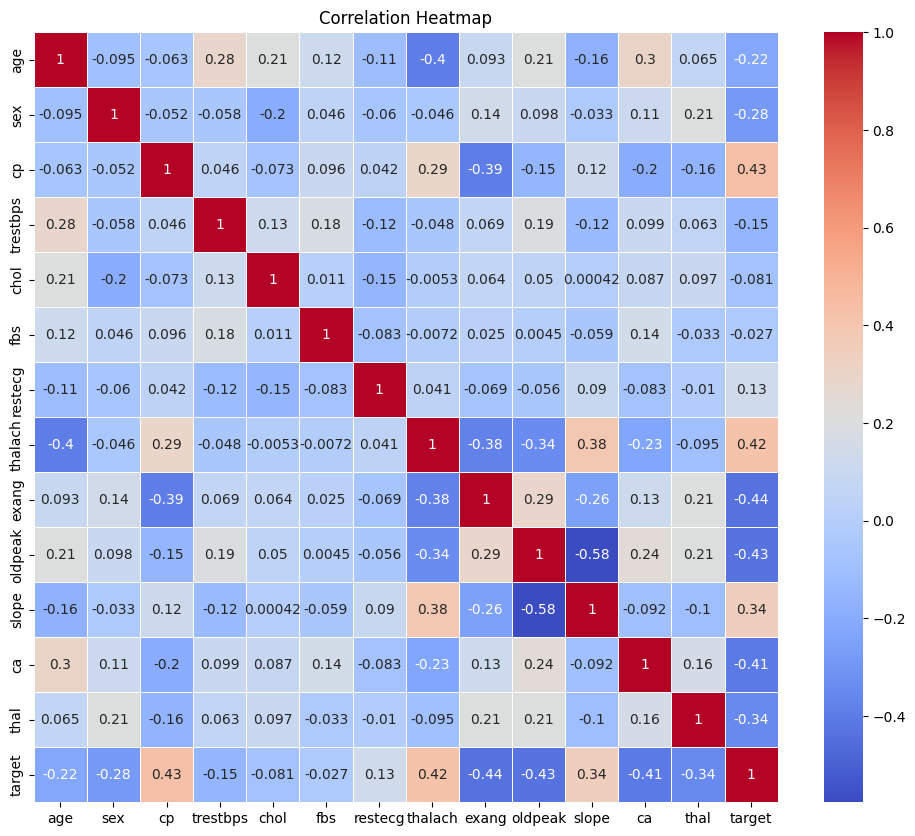

In [20]:
# Coorelation heatmap 

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

The correlation chart shows that cp(chest pain) has a positive coorelation. More chest pain = more disease 

exang(exercise angina) : Exercise induced pain = less disease 

The heatmap will tell you what are the important features. Age is surprisinly weak 

In [21]:
df.corr()['target'].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

In [22]:
# Prepare the data for train test split

from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training data size: {len(X_train)}')
print(f'Test data size: {len(X_test)}')

Training data size: 241
Test data size: 61


In [23]:
# We will train three models and compare them 


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#MModel1: Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)
lr.pred= lr.predict(X_test)

print(f"Logistic Regression: {accuracy_score(y_test, lr.pred): .2%}")

#Model 2: Random Forest Classifier

rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.pred = rf.predict(X_test)
print(f"Random Forest: {accuracy_score(y_test, rf.pred): .2%}")

#Model 3: Support Vector Machine

svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm.pred = svm.predict(X_test)
print(f"Support Vector Machine: {accuracy_score(y_test, svm.pred): .2%}")

Logistic Regression:  80.33%
Random Forest:  75.41%
Support Vector Machine:  60.66%


Logistic Regression is the winner, random forest needs tuning since its underperforming, SVM needs feature scaling 

Since SVM is very senstive to feature ranges since age is ranging from 29-77, but ch0olesterol ranges from 100-600. SVM thinks cholesterol is more important just beasue the numbers are bigger 

In [25]:
# Fix SVM using feature scaling 

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#FIX SVM with scaling 

svm_pipeline= Pipeline([
    ('scaler', StandardScaler()), 
    ('svm', SVC(random_state=42))
])

svm_pipeline.fit(X_train, y_train)
svm_pipeline.pred = svm_pipeline.predict(X_test)
print(f"SVM with Scaling: {accuracy_score(y_test, svm_pipeline.pred): .2%}")

SVM with Scaling:  77.05%


In [26]:
print("===Logistic Regression Classification Report===")  
print(classification_report(y_test, lr.pred))
print("===Random Forest Classification Report===")
print(classification_report(y_test, rf.pred))
print("===SVM with Scaling Classification Report===")     
print(classification_report(y_test, svm_pipeline.pred))

===Logistic Regression Classification Report===
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

===Random Forest Classification Report===
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61

===SVM with Scaling Classification Report===
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77    

If we look at the logistic regression classification report. we have the following analysi:
1) Support : 33 -> there are 33 actual disease patients in the test set 
2) Recall = 0.85 -> We correctly caught 85% of the sick patients (28 out of 33)
3) Precision = 0.80 -> When we said sick, we were right 80% of the time 
4) F1 =0.82 -> balanced score between precisioin and recall 

Conclusion : We missed 15% of sick patients since recall is 0.85

In [31]:
# Lets finetune our best model (Logistic Regression)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [100, 200, 500,1000]
}   

grid_search = GridSearchCV(
  
  estimator=LogisticRegression(random_state=42), param_grid=param_grid,
  cv=5, 
  scoring = 'recall', 
  n_jobs=-1, 
  verbose=2)


grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Hyperparameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Recall Score: 0.9011


c:\Users\sahil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


test accuracy:  81.97%
classification_report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



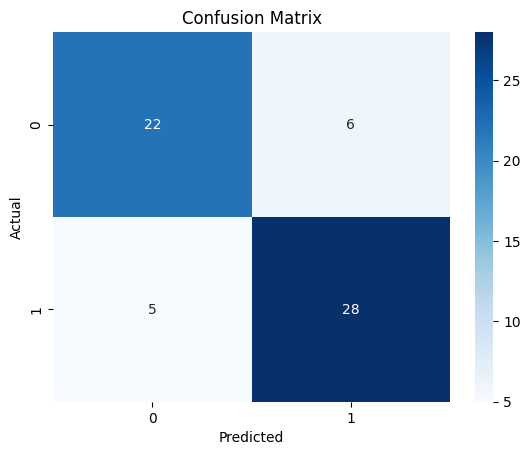

In [32]:
# Train the final model with best paramenters 

best_model = grid_search.best_estimator_

#Predict on test set 

y_pred = best_model.predict(X_test)

#final evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"test accuracy: {accuracy_score(y_test, y_pred): .2%}")
print(f"classification_report:\n{classification_report(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


The fine tuning helped in improving the precision and F1 score, meaning the model became more confident and accurate overall without sacrificing its ability to catch sick patients 

     Feature  Coefficient  Abs_Coefficient
2         cp     0.713188         0.713188
1        sex    -0.680076         0.680076
12      thal    -0.540395         0.540395
11        ca    -0.531799         0.531799
8      exang    -0.446067         0.446067
9    oldpeak    -0.358760         0.358760
10     slope     0.195368         0.195368
6    restecg     0.165516         0.165516
5        fbs    -0.071582         0.071582
7    thalach     0.031288         0.031288
3   trestbps    -0.018624         0.018624
0        age     0.007880         0.007880
4       chol    -0.004001         0.004001


C:\Users\sahil\AppData\Local\Temp\ipykernel_46532\896405199.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feat_importance, palette='coolwarm')


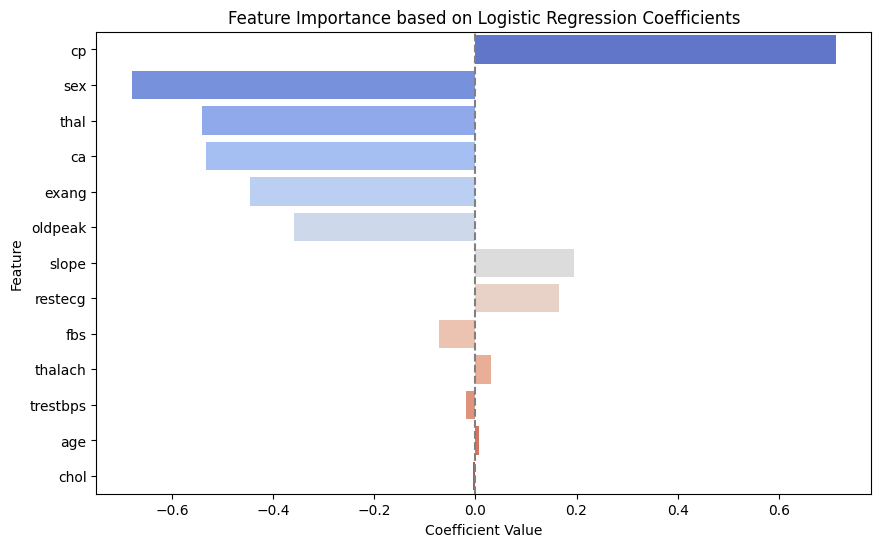

In [33]:
# Get feature importance from the best model

import pandas as pd
import numpy as np


feature_names = X.columns
coefficients = best_model.coef_[0]

feat_importance = pd.DataFrame({
    'Feature': feature_names, 
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients) 
}).sort_values(by='Abs_Coefficient', ascending=False)

print(feat_importance)

# Plot it

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feat_importance, palette='coolwarm')
plt.title('Feature Importance based on Logistic Regression Coefficients')
plt.xlabel('Coefficient Value') 
plt.ylabel('Feature')
plt.axvline(0, color='grey', linestyle='--')
plt.show()

Insights: Cholesterol and age - which most people assume are the biggest risk factors for heart disease - are actually less important in our model than other features like chest pain type and maximum heart rate. 

In [34]:
import joblib 
import os

#Create a model/folder 

os. makedirs('models', exist_ok=True)

#Save the best model 
joblib.dump(best_model, 'models/heart_disease_model.pkl')

#Save the features names 

feature_names = X.columns.tolist()
joblib.dump(feature_names, 'models/heart_disease_features.pkl')

print(f"Model saved to models/heart_disease_model.pkl")
print(f"Features saved to models/heart_disease_features.pkl") 
print(f"feature_names: {feature_names}")  

Model saved to models/heart_disease_model.pkl
Features saved to models/heart_disease_features.pkl
feature_names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
